# RL - Chapter 5 - Monte Carlo - Racetrack Problem


In [46]:
from toc import generate_toc

path = 'ch_5_MC_p1_racetrack.ipynb'
generate_toc(path)

## Table of Contents

- [RL - Chapter 5 - Monte Carlo - Racetrack Problem](#rl-chapter-5-monte-carlo-racetrack-problem)
  - [Racetrack environment](#racetrack-environment)
  - [Off-policy Monte Carlo Control](#off-policy-monte-carlo-control)

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# set decimal precision for numpy arrays
np.set_printoptions(precision=1, suppress=True)

## Racetrack environment


In [48]:

# define the racetrack environment
class Racetrack:
    def __init__(self):
        n_rows, n_cols = 32, 17
        self.track = np.ones((n_rows, n_cols), dtype=int)
        # free space
        self.track[1:-1, 4:10] = 0
        self.track[3:30, 3] = 0
        self.track[10:29, 2] = 0
        self.track[19:28, 1] = 0
        self.track[28:29, 2] = 0
        self.track[29:31, 3] = 0
        self.track[30, 4] = 0
        #
        self.track[25, 2:10] = 0
        self.track[26:-1, 10:-1] = 0

        # self.start_line = [0, 4:9]
        self.track[1, 4:10] = 2
        # self.finish_line = [16, 26:]
        self.track[26:31, 15] = 3

        # flatten the track for easier state representation
        self.flat_track = self.track.flatten()

        # velocity limits
        self.v_min = 0
        self.v_max = 5

        # actions are all combinations of acceleration in x and y directions
        dv = [(ax, ay) for ax in range(-1, 2) for ay in range(-1, 2)]
        # remove the action that does not change velocity (0, 0)
        self.dv = dv
        self.actions = range(len(self.dv))
        self.n_actions = len(self.actions)

        dv_non_zero = [a for a in self.dv if a != (0, 0)]
        self.dv_non_zero = dv_non_zero

        #
        self.viz_map = None
        self.create_viz_map()

    def get_random_start(self):
        start_positions = np.argwhere(self.track == 2)
        xy = tuple(start_positions[np.random.choice(len(start_positions))])
        v = (0, 0)  # start with zero velocity
        return (xy, v)

    def is_open_space(self, pos):
        return self.track[pos[0], pos[1]] == 0

    def is_finish_line(self, pos):
        return self.track[pos[0], pos[1]] == 3

    def is_occupied(self, pos):
        return self.track[pos[0], pos[1]] == 1

    def is_out_of_bounds(self, pos):
        return (pos[0] < 0 or pos[0] >= self.track.shape[0] or
                pos[1] < 0 or pos[1] >= self.track.shape[1])

    def create_viz_map(self):
        # start red, finish green, free space white, and boundaries black
        viz_map = np.zeros((*self.track.shape, 3), dtype=int)
        viz_map[self.track == 0] = [255, 255, 255]  # free space white
        viz_map[self.track == 1] = [0, 0, 0]    # boundaries black
        viz_map[self.track == 2] = [255, 0, 0]  # start line red
        viz_map[self.track == 3] = [0, 255, 0]  # finish line green
        self.viz_map = viz_map

    def plot_map(self):
        _, ax = plt.subplots(figsize=(6, 12))
        viz_map = np.flipud(self.viz_map)
        ax.imshow(viz_map)
        ax.axis('off')
        plt.show()

    def plot_map_path(self, path):
        _, ax = plt.subplots(figsize=(6, 12))
        ax.imshow(self.viz_map)
        ax.plot(path[:, 1], path[:, 0], marker='o', color='blue')
        ax.axis('off')
        plt.show()

## Off-policy Monte Carlo Control


In [49]:
# off-policy Monte Carlo control with weighting importance sampling
class MonteCarloControl:
    def __init__(self, env: Racetrack, gamma=0.9):
        self.env = env
        self.gamma = gamma
        self.Q = defaultdict(float)     # action-value function
        self.C = defaultdict(float)     # cumulative weights for importance sampling
        self.pi = {}                    # target policy (greedy)
        self.max_episodes = 2000
        self.max_steps = 1000

    def control(self):
        crash_window = []
        for e in range(self.max_episodes):
            episode, n_crashes = self.generate_episode()
            crash_window.append(n_crashes)

            G = 0
            W = 1
            for t in reversed(range(len(episode))):
                state, action, reward, b = episode[t]
                G = self.gamma * G + reward
                self.C[(state, action)] += W
                self.Q[(state, action)] += (W / self.C[(state, action)]) * (G - self.Q[(state, action)])

                greedy_action = self.greedy_policy(state)
                self.pi[state] = greedy_action
                if action != greedy_action:
                    break

                W *= 1 / b

            if (e + 1) % 100 == 0:
                avg_crashes = np.mean(crash_window[-100:])
                finish_rate = np.mean([1 if c < self.max_steps else 0 for c in crash_window[-100:]])
                print(f"Episode {e+1}/{self.max_episodes} | avg crashes(100): {avg_crashes:.1f} | finish proxy: {finish_rate:.2f}")

    def generate_episode(self):
        episode = []
        state = self.env.get_random_start()
        n_crashes = 0
        for _ in range(self.max_steps):
            action, b, _ = self.behavior_policy(state)
            next_state, reward, done, crashed = self.take_action(state, action)
            episode.append((state, action, reward, b))
            if crashed:
                n_crashes += 1
            if done:
                break
            state = next_state
        return episode, n_crashes

    def behavior_policy(self, state):
        '''epsilon-soft behavior policy.'''
        best_action = self.greedy_policy(state)
        epsilon = 0.2
        p_actions = np.ones(self.env.n_actions) * (epsilon / self.env.n_actions)
        p_actions[best_action] += (1 - epsilon)
        selected_action = np.random.choice(self.env.n_actions, p=p_actions)
        b = p_actions[selected_action]
        pi = 1.0 if selected_action == best_action else 0.0
        return selected_action, b, pi

    def take_action(self, state, action):
        '''returns next_state, reward, done based on the action taken from the current state.
            Returns:
                next_state, reward, done, crashed
        '''
        new_v = self.update_velocity(state, action)
        next_pose = (state[0][0] + new_v[0], state[0][1] + new_v[1])
        next_state = (next_pose, new_v)
        poses = self.get_line_points(state, next_state)
        for pos in poses:
            if self.env.is_out_of_bounds(pos) or self.env.is_occupied(pos):
                state = self.env.get_random_start()
                return state, -1, False, True
            if self.env.is_finish_line(pos):
                next_state = (pos, new_v)
                return next_state, 0, True, False
        return next_state, -1, False, False

    def greedy_policy(self, state):
        '''greedy policy based on current Q-values.'''
        q_vals = [self.Q[(state, a)] for a in self.env.actions]
        max_q = max(q_vals)
        return np.random.choice([a for a, q in zip(self.env.actions, q_vals) if q == max_q])

    def update_velocity(self, state, action):
        '''update velocity based on the action taken.'''
        velocity = state[1]
        d_xy = self.env.dv[action]
        new_velocity = (velocity[0] + d_xy[0], velocity[1] + d_xy[1])
        new_velocity = np.clip(new_velocity, self.env.v_min, self.env.v_max)
        new_velocity = tuple(new_velocity)

        # avoid (0, 0) after start with a deterministic small forward kick
        if new_velocity == (0, 0):
            new_velocity = velocity
            if new_velocity == (0, 0):
                new_velocity = (1, 0)
        return new_velocity

    def get_line_points(self, state, next_state):
        '''check if the path from state to next_state passes through the finish line.'''
        start_pos = state[0]
        end_pos = next_state[0]
        len = np.linalg.norm(np.array(end_pos) - np.array(start_pos))
        if len < 1:
            return [end_pos]
        poses = []
        steps = int(np.ceil(len))
        lx = np.linspace(start_pos[0], end_pos[0], steps)
        ly = np.linspace(start_pos[1], end_pos[1], steps)
        for x, y in zip(lx, ly):
            pos = (int(round(x)), int(round(y)))
            poses.append(pos)
        return poses

In [50]:
# run the control algorithm

# create the racetrack environment
race = Racetrack()
# race.plot_map()

# initialize the Monte Carlo control agent
mc_control = MonteCarloControl(race)
mc_control.control()

Episode 100/2000 | avg crashes(100): 137.1 | finish proxy: 1.00
Episode 200/2000 | avg crashes(100): 136.5 | finish proxy: 1.00
Episode 300/2000 | avg crashes(100): 128.6 | finish proxy: 1.00
Episode 400/2000 | avg crashes(100): 143.4 | finish proxy: 1.00
Episode 500/2000 | avg crashes(100): 152.4 | finish proxy: 1.00
Episode 600/2000 | avg crashes(100): 145.8 | finish proxy: 1.00
Episode 700/2000 | avg crashes(100): 132.1 | finish proxy: 1.00
Episode 800/2000 | avg crashes(100): 143.1 | finish proxy: 1.00
Episode 900/2000 | avg crashes(100): 136.6 | finish proxy: 1.00
Episode 1000/2000 | avg crashes(100): 147.6 | finish proxy: 1.00
Episode 1100/2000 | avg crashes(100): 153.0 | finish proxy: 1.00
Episode 1200/2000 | avg crashes(100): 140.8 | finish proxy: 1.00
Episode 1300/2000 | avg crashes(100): 129.3 | finish proxy: 1.00
Episode 1400/2000 | avg crashes(100): 139.5 | finish proxy: 1.00
Episode 1500/2000 | avg crashes(100): 134.3 | finish proxy: 1.00
Episode 1600/2000 | avg crashes(10

Episode finished.
Number of crashes: 23


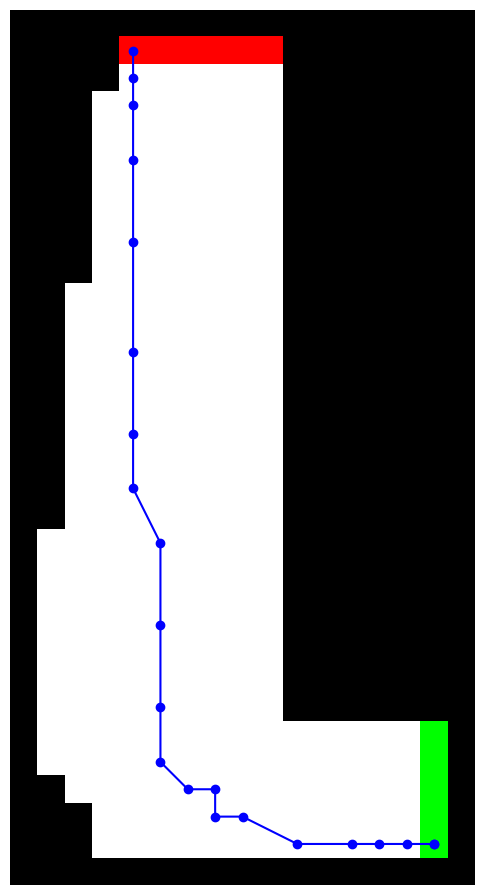

In [69]:
# results
# startiing from one of the start positions, we can follow the greedy policy to see the learned optimal path to the finish line.
n_crashes = 0
state = tuple(race.get_random_start())
path = [state[0]]
while True:
    action = mc_control.greedy_policy(state)
    next_state, reward, done, crashed = mc_control.take_action(state, action)

    if crashed:
        n_crashes += 1
        path = [next_state[0]]  # reset path to current position after crash
    else:
        path.append(next_state[0])
    state = next_state

    if done:
        print("Episode finished.")
        break

    if len(path) > 1000:  # prevent infinite loops in case of failure
        print("Too many steps, stopping.")
        break

print(f"Number of crashes: {n_crashes}")

# visualize the path on the racetrack
race.plot_map_path(np.array(path))

In [52]:
# save the learned Q-values for later analysis
import pickle
with open('ch_5_p1_q_values_1.pkl', 'wb') as f:
    pickle.dump(dict(mc_control.Q), f)

In [53]:
# # load the Q-values back for analysis
# with open('ch_5_p1_q_values_1.pkl', 'rb') as f:
#     loaded_Q = pickle.load(f)
#     mc_control.Q = loaded_Q